In [8]:
import csv
import random
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ks_2samp, ttest_ind

# =====================================================================
# STEP 1: FRESH FILE INGESTION (RESETS VARIABLE MEMORY)
# =====================================================================
genes_list = []
data_rows = []

with open("C:/Users/vikas/Documents/BioPythonTutorial/GSE150910_gene-level_count_file.csv") as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    for row in reader:
        genes_list.append(row[0])
        data_rows.append(row[1:])

# Extract your baseline text structures
samples = np.array(data_rows[0])
data_raw = data_rows[1:]
genes_raw = genes_list[1:]

# Convert numbers from text strings to floats, filling gaps with 0
data = np.array(data_raw)
data[data == ""] = "0"
data = data.astype(float)
genes = np.array(genes_raw)

# =====================================================================
# STEP 2: ISOLATE DISEASES & DROP THE CHP COHORT
# =====================================================================
labels = np.array([s.split("_")[0].strip().lower() for s in samples])

# Slicing the columns (Patients)
data = data[:, labels != "chp"]
samples = samples[labels != "chp"]
labels = labels[labels != "chp"]

# =====================================================================
# STEP 3: HIGH-SPEED VECTORIZED CPM NORMALIZATION (REPLACES LOOPS)
# =====================================================================
column_sums = np.nansum(data, axis=0)
column_sums[column_sums == 0] = 1  # Prevents dividing by zero
data = (data / column_sums) * 1000000

# =====================================================================
# STEP 4: FILTER OUT LOW-EXPRESSION GENES (SAFE SYNCED ROW SLICING)
# =====================================================================
mean_CPM_control = np.nanmean(data[:, labels == "control"], axis=1)
mean_CPM_ipf = np.nanmean(data[:, labels == "ipf"], axis=1)

# Compile Mike's cutoff logical filter
to_keep = (mean_CPM_ipf >= 5) | (mean_CPM_control >= 5)

# Slice both rows simultaneously to guarantee absolute length sync!
data = data[to_keep, :]
genes = genes[to_keep]

# Re-compute group means on the synchronized clean subset
mean_CPM_control = mean_CPM_control[to_keep]
mean_CPM_ipf = mean_CPM_ipf[to_keep]

# =====================================================================
# STEP 5: EVALUATE TARGET LOG2 FOLD CHANGES
# =====================================================================
log2_fold_change = np.log2(mean_CPM_ipf + 1) - np.log2(mean_CPM_control + 1)

print("=== PIPELINE STACK SUCCESS ===")
print(f"Final Data Matrix Shape : {data.shape}")
print(f"Total Aligned Gene Names: {len(genes)}")
print(f"Mean Control Vector Size: {len(mean_CPM_control)}")
print(f"Mean IPF Vector Size    : {len(mean_CPM_ipf)}")
print(f"Top Extracted Target    : {genes[0] if len(genes) > 0 else 'None'}")


=== PIPELINE STACK SUCCESS ===
Final Data Matrix Shape : (11097, 206)
Total Aligned Gene Names: 11097
Mean Control Vector Size: 11097
Mean IPF Vector Size    : 11097
Top Extracted Target    : TSPAN6


In [9]:
control=data[0,labels=="control"]
ipf=data[0,labels=="ipf"]

In [10]:
print(control.shape)
print(ipf.shape)

(103,)
(103,)


In [11]:
ks_statistics,p_value=ks_2samp(control,ipf)
print(f"ks_statistics value : {ks_statistics}")
print(f"p_value value : {p_value}")

ks_statistics value : 0.4368932038834951
p_value value : 3.264129457102852e-09


In [12]:
epsilon =1 # avoid by dividing with 0
control_mean=np.mean(control)
ipf_mean=np.mean(ipf)
fc= (control_mean+epsilon)/(ipf_mean+epsilon)
log2_fc=np.log2(fc)
print(f"log2 fold change is : {log2_fc}")
print(fc)

log2 fold change is : -0.7894289821093975
0.5785730455277578


In [18]:
# getting p-values and log2fc for every gene
p_values=[]
log2_FC=[]
epsilon =1

for i in range(data.shape[0]):
    control =data[i,labels=="control"]
    ipf=data[i,labels=="ipf"]

    #perform k test p-value 
    kd_statistics,p_value=ks_2samp(control,ipf)
    #save p-value
    p_values.append(p_value)

    #calculate means for every gene
    control_mean=np.mean(control)
    ipf_mean=np.mean(ipf)
    
    #calculate fold change and add epsilon to avoid dividing by 0
    
    fc=(control_mean+epsilon)/(ipf_mean+epsilon)
    log2_fc=np.log2(fc)
    #save log2_fc 
    log2_FC.append(log2_fc)

#save values in array
p_values=np.array(p_values)

In [19]:
# bonferroni correction each gene p-values are multipy by no of test did
p_bonf_values=p_values * len(genes)

In [21]:
# 1. Calculate Bonferroni adjusted p-values safely
p_bonf_values = np.minimum(p_values * len(genes), 1.0)

# 2. ──► THE CRUCIAL TRANSFORMATION LAYER ◄──
# Force every tracking container into a true 1-Dimensional NumPy Array!
p_bonf_values = np.array(p_bonf_values)
log2_FC       = np.array(log2_FC)
genes_array   = np.array(genes)  # Converts your text gene symbols list into a sliceable matrix

# 3. Create your high-stringency biological threshold mask
to_keep = (p_bonf_values <= 0.05) & (np.abs(log2_FC) >= 2)

# 4. Slice your multi-dimensional containers simultaneously using 'genes_array'
sig_genes         = genes_array[to_keep] # Use the new array version here!
sig_log2_FC       = log2_FC[to_keep]     # This will now pass without the TypeError!
sig_p_bonf_values = p_bonf_values[to_keep]
sig_data          = data[to_keep, :]

print("=== COHORT MATRIX INDEXING SUCCESS ===")
print(f"Total statistically undeniable IPF biomarkers found: {len(sig_genes)}")



=== COHORT MATRIX INDEXING SUCCESS ===
Total statistically undeniable IPF biomarkers found: 79


In [22]:
print(f"number of DEGS :{len(sig_genes)}")
print(f" total number of genes :{len(genes)}")
print(f"DEG percentage :{(len(sig_genes)/len(genes))*100}")
print()
print(f"number of unregulated genes :{np.sum(sig_log2_FC>0)}")
print(f"number of downgregulated genes :{np.sum(sig_log2_FC<0)}")

number of DEGS :79
 total number of genes :11097
DEG percentage :0.7119041182301523

number of unregulated genes :14
number of downgregulated genes :65


In [23]:
# list of DEGS
for i in range(len(sig_genes)):
    if sig_log2_FC[i]>0:
        print(sig_genes[i])

PRX
SLC6A4
MYRF
FCN3
GGTLC1
ITLN2
DEFA4
BTNL9
MS4A15
CA4
RTKN2
AGER
DEFA1
DEFA1B


In [24]:
# saving the result in csv files 
#saving unregulated DEGs

output_file="C:/Users/vikas/Documents/BioPythonTutorial/unregulated_DEGs.csv"
with open(output_file,mode='w',newline='') as file:
    writer=csv.writer(file)
    writer.writerow(["genes","p_values","log2_FC"])
    
    for i in range(len(sig_genes)):
        if(sig_log2_FC[i]>0):
            writer.writerow([sig_genes[i],sig_p_bonf_values[i],sig_log2_FC[i]])
            
# saving downregulated DEGs 
output_file="C:/Users/vikas/Documents/BioPythonTutorial/downregulated_DEGs.csv"
with open(output_file,mode='w',newline='') as file:
    writer=csv.writer(file)
    writer.writerow(["genes","p_values","log2_FC"])
    
    for i in range(len(sig_genes)):
        if sig_log2_FC[i]<0:
            writer.writerow([sig_genes[i],sig_p_bonf_values[i],sig_log2_FC[i]])
        

Heatmap Matrix Dimensions: (79, 206)


C:\Users\vikas\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\vikas\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


💾 Heatmap successfully saved to 'output/heatmap.pdf'!


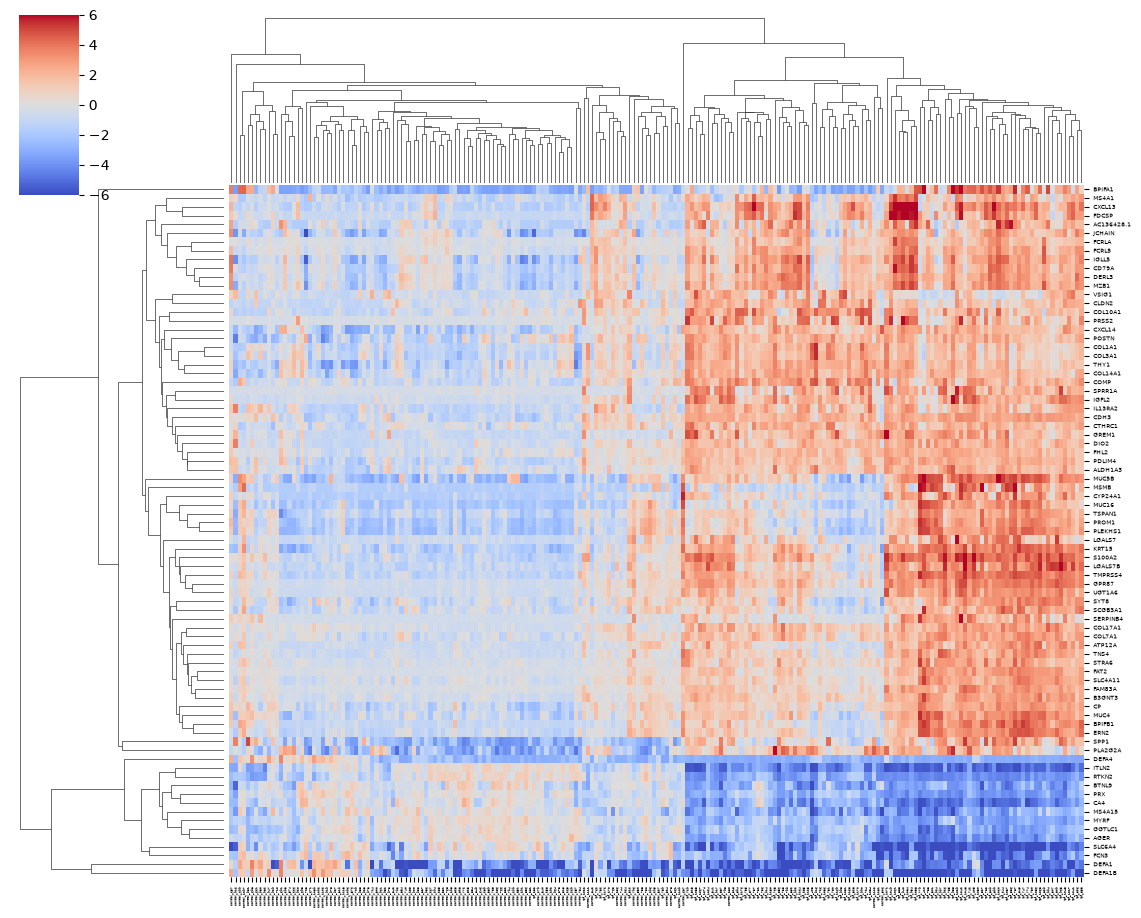

In [25]:
import os


# 1. Initialize your log2 fold change grid
sig_data_log2fc = np.zeros_like(sig_data)
print(f"Heatmap Matrix Dimensions: {sig_data.shape}")

epsilon = 1  # small constant to avoid division by zero

# 2. Compute the patient-relative Log2 ratio across all significant genes
for i in range(len(sig_genes)):
    # Calculate the average baseline counts for healthy controls for this specific gene
    control_mean = np.mean(sig_data[i, labels == "control"])

    # Compute relative log2 ratio for every individual patient sample
    sig_data_log2fc[i, :] = np.log2(
        (sig_data[i, :] + epsilon) / (control_mean + epsilon)
    )

# 3. Generate your beautiful coolwarm genomic clustermap
sns_plot = sns.clustermap(
    sig_data_log2fc,
    xticklabels=samples,
    yticklabels=sig_genes,
    cmap="coolwarm",
    vmin=-6,
    vmax=6,
    figsize=(12, 10),
)

# 4. Clean, direct way to set micro-fonts for massive datasets
plt.setp(sns_plot.ax_heatmap.get_xticklabels(), fontsize=2)
plt.setp(sns_plot.ax_heatmap.get_yticklabels(), fontsize=4)

# 5. ──► THE DIRECTORY GUARD: Create 'output/' folder if it doesn't exist yet!
if not os.path.exists("output"):
    os.makedirs("output")

# 6. Save the publication-quality vector graphic file
sns_plot.savefig("C:/Users/vikas/Documents/BioPythonTutorial/heatmap.pdf", bbox_inches="tight")
print("💾 Heatmap successfully saved to 'output/heatmap.pdf'!")

# Display the render straight to your screen layout
plt.show()


💾 Volcano Plot successfully saved to: C:/Users/vikas/Documents/BioPythonTutorial/volcano_plot_output.png


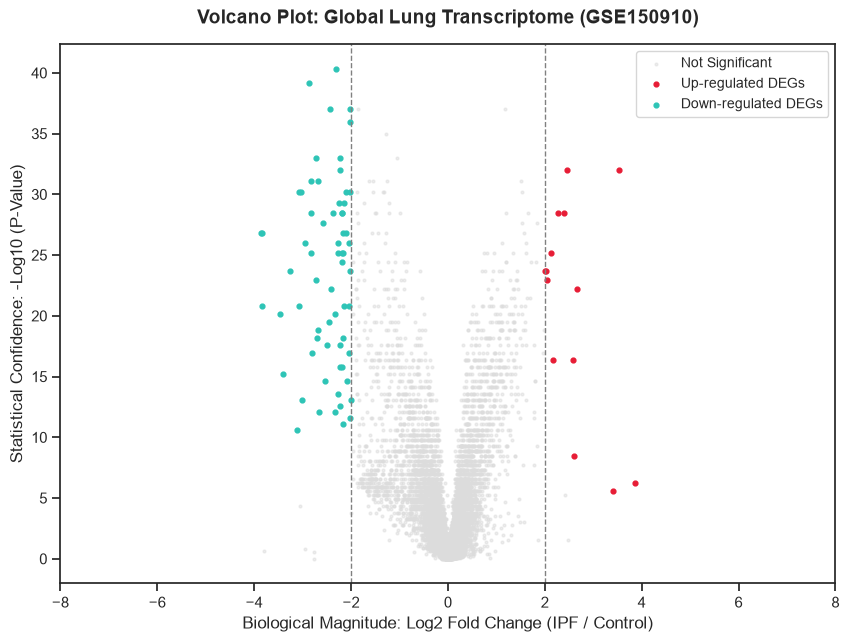

In [28]:
import os

# 1. Define your exact target directory path
target_directory = "C:/Users/vikas/Documents/BioPythonTutorial/"

# 2. Transform raw p-values into -log10 vertical axis scale
p_eps = 1e-300
neg_log10_p = -np.log10(p_values + p_eps)

# Re-create your threshold filtration markers
is_deg_up = (p_bonf_values <= 0.05) & (log2_FC >= 2)
is_deg_down = (p_bonf_values <= 0.05) & (log2_FC <= -2)

# 3. Setup the visual chart frame layout
plt.figure(figsize=(10, 7))
sns.set_theme(style="ticks")

# Layer 1: Plot all background noise genes (Grey Cloud)
plt.scatter(
    log2_FC, neg_log10_p, color="gainsboro", s=4, alpha=0.5, label="Not Significant"
)

# Layer 2: Highlight your highly significant up-regulated and down-regulated DEGs
plt.scatter(
    log2_FC[is_deg_up],
    neg_log10_p[is_deg_up],
    color="#e71d36",
    s=12,
    label="Up-regulated DEGs",
)
plt.scatter(
    log2_FC[is_deg_down],
    neg_log10_p[is_deg_down],
    color="#2ec4b6",
    s=12,
    label="Down-regulated DEGs",
)

# Layer 3: Plot threshold guidelines
plt.axvline(x=2, color="grey", linestyle="--", linewidth=1)
plt.axvline(x=-2, color="grey", linestyle="--", linewidth=1)

# Format titles and labels
plt.title(
    "Volcano Plot: Global Lung Transcriptome (GSE150910)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Biological Magnitude: Log2 Fold Change (IPF / Control)", fontsize=12)
plt.ylabel("Statistical Confidence: -Log10 (P-Value)", fontsize=12)
plt.legend(loc="upper right", frameon=True, fontsize=10)
plt.xlim(-8, 8)

# 4. ──► THE EXPORT STEP: Build path and save file BEFORE calling plt.show() ◄──
output_filename = "volcano_plot_output.png"
full_saving_path = os.path.join(target_directory, output_filename)

# Save as a 300 DPI high-resolution presentation image file
plt.savefig(full_saving_path, dpi=300, bbox_inches="tight")
print(f"💾 Volcano Plot successfully saved to: {full_saving_path}")

# Display the graphic on your monitor screen
plt.show()
